# Probability of Default

In this notebook, we shall build a model to compute the probability of default ($PD$) for a potential borrower using logistic regression on our feature set. We will use 80% of the feature set to train the model and the other 20% to validate.

### Motivation

We first discuss the motivation. Under IFRS 9, the $ECL$ (expected credit loss) is given by the following formula: $$ECL=PD\cdot LGD \cdot EAD.$$ Here, $PD$ is the probability of default as previously mentioned, $LGD$ is the loss given a default and $EAD$ is the exposure at default.

So we wish to create a model that computes these terms individually and takes the product at the end.

### Splitting the Data

Let us import our feature set and the required Python packages.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

#load feature set from 02
df = pd.read_csv('data/features.csv', index_col=0)
print(df.shape)

(99807, 25)


Now we separate the default flag, as this is what we are trying to predict with the model. We will later use this for validation.

In [3]:
#separate features from default flag
x = df.drop(columns=['default_flag'])
y = df['default_flag']
print(x.shape, y.shape)

(99807, 24) (99807,)


We split the data into 80% training data and 20% validation/test data. To do this, we use the `train_test_split` function, which splits the data into two groups at random. We choose a consistent seed such that the work may be reproduced using `random_state=99`. We also use `stratify=y` to ensure that the default rate is identical in both the training set and the validation set.

In [ ]:
#split into 80% training and 20% validation
#stratify=y ensures default rate is consistent across both splits
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

#print details of split to verify
print(f'Training rows: {len(x_train)}, Test rows: {len(x_test)}')
print(f'Training default rate: {y_train.mean():.3f}')
print(f'Test default rate: {y_test.mean():.3f}')

Training rows: 79845, Test rows: 19962
Training default rate: 0.132
Test default rate: 0.132


So our data has been split as required.

## The Mathematics of Logistic Regression

Before we begin to train the model, we first explain the theory behind logistic regression. This will lead nicely into discussion of its limitations.

### The Logistic Function

A **logistic function** is a mathematical function $f:\mathbb{R}\to (0,L)$ of the form $$f(t)= \frac{L}{1+e^{-k(t-t_0)}}.$$ Here, $k$ is some arbitrary constant (representing the 'logistic growth rate') and $t_0$ is the $t$ value of the midpoint of the function (i.e. $f(0)$), which is chosen. One can see that $L$ is the upper limit of this function, since $e^{-k(t-t_0)}>0$ necessarily. So as $t\to\infty$ we have $f(t)\to \frac{L}{1}=L$, which can be easily verified. The logistic function is a type of **sigmoid function**, which, informally, is the name for functions that produce 'S-shaped' curves.

The **standard logistic function** $\sigma:\mathbb{R}\to (0,1)$ is the logistic function with $L=1$, $k=1$ and $t_0=0$, shown below for $-10\leq t\leq 10$. 

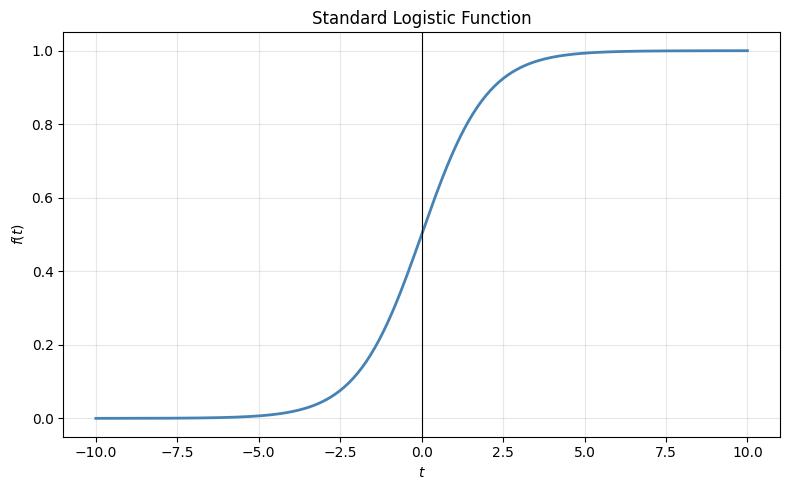

In [12]:
#standard logistic function
t = np.linspace(-10, 10, 300)
y = 1 / (1 + np.exp(-t))

plt.figure(figsize=(8, 5))
plt.plot(t, y, color='steelblue', linewidth=2)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title("Standard Logistic Function")
plt.xlabel("$t$")
plt.ylabel("$f(t)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Independent Variables

Suppose now that we have $$t=\beta_0+\sum_{i=1}^{n}\beta_i x_i$$ in our standard logistic function. The $x_i$ are **independent variables** (in our case, these are equivalent to our features); the $\beta_i$ represent constant coefficients to be found.

### Computing the Probability

Given some features $x_1,\dots,x_n$ with known coefficients $\beta_0, \dots,\beta_n$ (note that $\beta_0$ does not have a corresponding feature) and $t$ as above, we can calculate the probability of some event $A$ occurring (when we come to apply logistic regression to the risk of default, then event $A$ will of course be the event of a default). We shall later return to the question of computing the coefficients $\beta_i$.

We first note that the standard logistic function at $t=\beta_0+\sum_{i=1}^{n}\beta_i x_i$ is given by $$\sigma(t)=\frac{1}{1+e^{-1(t-0)}}=\frac{1}{1+e^{-t}}=\frac{1}{1+e^{-(\beta_0+\beta_1 x_1 +\dots+\beta_n x_n)}}.$$ Then the probability of $A$, denoted $P(A)$, is given by $$P(A)=\sigma(t)=\frac{1}{1+e^{-(\beta_0+\beta_1 x_1 +\dots+\beta_n x_n)}}.$$ It is trivial to see that $0< P(A) < 1$ by nature of the standard logistic function.

Let us rearrange the equation for the probability of $A$ to obtain $$e^{-t}=\frac{1}{P(A)}-1.$$ This then gives $$e^{-t}=\frac{1-P(A)}{P(A)}.$$ We can take the natural logarithm to get $$-t=\beta_0+\sum_{i=1}^{n}\beta_i x_i=\ln(\frac{{1-P(A)}}{P(A)}).$$






